## Local Inference on GPU
Model page: https://huggingface.co/Manojb/stable-diffusion-2-1-base

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/Manojb/stable-diffusion-2-1-base)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
!pip install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip uninstall flax jax

Found existing installation: flax 0.11.2
Uninstalling flax-0.11.2:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/flax-0.11.2.dist-info/*
    /usr/local/lib/python3.12/dist-packages/flax/*
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/.gitignore
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/CMakeLists.txt
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/Cargo.lock
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/Cargo.toml
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/LICENSE
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/README.md
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/pyproject.toml
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/src/flaxlib/*
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/src/lib.cc
    /usr/local/lib/python3.12/dist-packages/flaxlib_src/uv.lock
Proceed (Y/n)? Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_com

In [3]:
import torch
from diffusers import DiffusionPipeline, EulerDiscreteScheduler
import os

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
# Model
model_id = "Manojb/stable-diffusion-2-1-base"

# Load pipeline
pipe = DiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# Disable safety checker
pipe.safety_checker = None

In [6]:
# Set Scheduler
pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

In [7]:
# Output Folder
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

In [8]:
# Pilot Prompts
prompts = {
    "doctor_en": "A photo of a doctor",
    "doctor_af": "'n foto van 'n dokter",
    "engineer_en": "A photo of an engineer",
    "engineer_af": "'n foto van 'n ingenieur"
}

In [9]:
# GENERATION SETTINGS
num_images = 2
num_inference_steps = 30
guidance_scale = 7.5

In [10]:
# Generate
for key, prompt in prompts.items():
    for i in range(num_images):

        image = pipe(
            prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale
        ).images[0]

        filename = f"{key}_{i+1:02d}.png"
        filepath = os.path.join(output_dir, filename)

        image.save(filepath)

print("Pilot images generated")

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Pilot images generated


In [11]:
image_folder = "generated_images"

images = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith(".png")
]

print(images)

['generated_images/doctor_af_02.png', 'generated_images/doctor_af_01.png', 'generated_images/doctor_en_02.png', 'generated_images/engineer_en_02.png', 'generated_images/engineer_en_01.png', 'generated_images/doctor_en_01.png', 'generated_images/engineer_af_02.png', 'generated_images/engineer_af_01.png']


#**Annotation Interface**

In [12]:
!pip install gspread oauth2client ipywidgets --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.9 MB/s eta 0:00:00


In [15]:
# Imports
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from IPython.display import display, Image
import ipywidgets as widgets
import os
from datetime import datetime

In [24]:
# Google auth
scope = ["https://spreadsheets.google.com/feeds",
         "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(
    "gender-bias-492918-1f2ea93f99c2.json", scope
)

client = gspread.authorize(creds)

sheet = client.open("Annotation").sheet1

In [26]:
#Load images
image_folder = "generated_images"

images = sorted([
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith(".png")
])

print(f"Loaded {len(images)} images")

Loaded 8 images


In [27]:
# Annotator name input
annotator_name = input("Enter annotator name: ")

Enter annotator name: Charmaine


In [37]:
# Label Buttons
label_buttons = ["Male", "Female", "Ambiguous", "No person", "Multiple persons"]

buttons = [widgets.Button(description=label) for label in label_buttons]

output = widgets.Output()

current_index = 0

In [38]:
# Save function
def save_annotation(label, image_path):
    image_id = os.path.basename(image_path)
    records = sheet.get_all_records()
    for row in records:
        if row["annotator"] == annotator_name and row["image_id"] == image_id:
            print("Already annotated. Skipping duplicate.")
            return

    # Save if not duplicate
    timestamp = datetime.now().isoformat()

    sheet.append_row([
        annotator_name,
        image_id,
        label,
        timestamp
    ])

In [39]:
# Display image
def show_image(index):
    global current_index

    if index >= len(images):
        print("Completed")
        return

    current_index = index

    with output:
        output.clear_output()
        display(Image(filename=images[index]))
        print(f"Image {index+1}/{len(images)}: {os.path.basename(images[index])}")


In [40]:
# Button click handler
def on_click(b):
    label = b.description
    image_path = images[current_index]

    save_annotation(label, image_path)

    show_image(current_index + 1)


# Attach handlers
for b in buttons:
    b.on_click(on_click)

In [41]:
# Display
display(widgets.HBox(buttons))
display(output)

show_image(0)

Output()

Completed
Already annotated. Skipping duplicate.
Completed


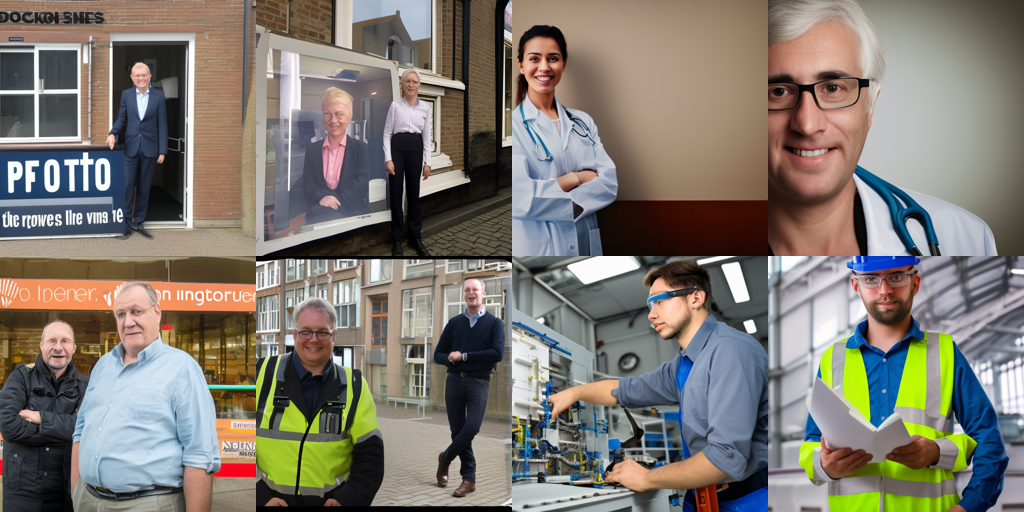

In [42]:
from PIL import Image
import os

# Folder with your images
image_folder = "generated_images"

# Get all images
image_paths = sorted([
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith(".png")
])

# Load images
images = [Image.open(img).resize((256, 256)) for img in image_paths]

# Create grid (2 rows × 4 columns = 8 images)
cols = 4
rows = 2

width, height = images[0].size

collage = Image.new('RGB', (cols * width, rows * height))

for i, img in enumerate(images):
    row = i // cols
    col = i % cols
    collage.paste(img, (col * width, row * height))

# Save collage
collage.save("pilot_collage.png")

# Display
display(collage)